# Week 6 

# Monday - 04/27 - Daily Practice

Part 1: Coding Challenge (40 min)

Build a regression model to predict diabetes progression using PyTorch.

Requirements:

- Use from sklearn.datasets import load_diabetes
- Build a 4-layer FC network with BatchNorm1d and Dropout
- Normalize features (StandardScaler)
- Train/val/test split (60/20/20)
- Track MSE loss and MAE during training
- Use AdamW optimizer with weight_decay
- Use CosineAnnealingLR scheduler
- Report final test MAE and MSE

From memory! This tests if you can handle regression confidently now.

It's regression. It's sklearn --> dataloader, we're doing train val test, mse and mae. 

In [2]:
import torch
import torchvision

from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import torch.nn as nn

from torch import optim

In [1]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

X, y = diabetes.data, diabetes.target

In [4]:
def pytorch_normalize(X_tensor):
    mean = X_tensor.mean(dim=0,keepdim=True)
    std = X_tensor.std(dim=0,keepdim=True)
    return (X_tensor-mean)/std

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

In [7]:
#1, Convert X's to tensors
X_train = torch.tensor(X_train,dtype=torch.float32)
X_val = torch.tensor(X_val,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)

#2. Convert y's to tensors
y_train = torch.tensor(y_train,dtype=torch.float32).reshape(-1,1)
y_val = torch.tensor(y_val,dtype=torch.float32).reshape(-1,1)
y_test = torch.tensor(y_test,dtype=torch.float32).reshape(-1,1)
# regression has torch.float32 and .reshape(-1,1) but classification will have just torch.tensor(source,dtype=torch.long) for the integer labels

#2.5 Normalize
X_train_normalized = pytorch_normalize(X_train)
X_val_normalized = pytorch_normalize(X_val)
X_test_normalized = pytorch_normalize(X_test)

#3. TensorDataset
train_dataset = TensorDataset(X_train_normalized, y_train)
val_dataset = TensorDataset(X_val_normalized, y_val)
test_dataset = TensorDataset(X_test_normalized, y_test)

#4. Dataloaders 
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32)
test_dataloader = DataLoader(test_dataset, batch_size=32)

In [12]:
input_shape = X.shape[1] #10 features

In [13]:
class Regressor(nn.Module):

    def __init__(self,input_shape):
        super().__init__()
        self.input_shape = input_shape

        self.linear_stack = nn.Sequential(
            nn.Linear(input_shape,32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(32,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64,32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.output = nn.Linear(32,1)

    def forward(self,x):
        x = self.linear_stack(x)
        logits = self.output(x)
        return logits

In [14]:
class EarlyStopping:

    def __init__(self,patience=5,min_delta=0):
        self.patience = patience #how many epochs to wait after last improvement 
        self.min_delta = min_delta #minimum change to qualify as improvement
        self.counter = 0 
        self.best_loss = None
        self.early_stop = False

    def __call__(self,val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter+=1
            print(f'EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                # kill it 
                self.early_stop=True
        else:
            #here is the reset. 
            self.best_loss = val_loss
            self.counter = 0 

In [16]:
model = Regressor(input_shape)
optimizer = optim.AdamW(model.parameters(),lr=0.001,weight_decay=1e-5)
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=100,eta_min=1e-6)
loss_fn = nn.MSELoss()

In [19]:
train_losses = []
val_losses = []

In [17]:
def train_loop(model,optimizer,loss_fn,lr_scheduler,train_dataloader,val_dataloader,train_losses,val_losses,early_stopping,epochs=100):

    best_loss = float("inf")

    for epoch in range(epochs):

        # == TRAINING ==

        model.train()
        train_loss = 0.0
        train_mae = 0.0

        for X_train,y_train in train_dataloader:

            optimizer.zero_grad()
            y_pred = model(X_train)
            loss = loss_fn(y_pred,y_train)
            loss.backward()
            optimizer.step()

            train_loss+=loss.item()

            #MAE PORTION
            with torch.no_grad():
                mae_curr = torch.abs(y_train-y_pred).mean()
                train_mae += mae_curr.item()

        avg_train_loss = train_loss/len(train_dataloader)
        avg_train_mae = train_mae/len(train_dataloader)
        train_losses.append(avg_train_loss)
        if (epoch+1==1) or ((epoch+1)%10==0):
            print(f"Epoch {epoch+1} | Train MSE: {avg_train_loss}")
            print(f"Epoch {epoch+1} | Train MAE: {avg_train_mae}")
        
        # == VAL ==

        model.eval()
        val_loss = 0.0
        val_mae = 0.0

        with torch.no_grad():

            for X_val,y_val in val_dataloader:

                y_pred = model(X_val)
                loss = loss_fn(y_pred,y_val)
                mae_curr = torch.abs(y_val-y_pred).mean()
                
                val_loss += loss.item()
                val_mae += mae_curr.item()

        avg_val_loss = val_loss/len(val_dataloader)
        avg_val_mae = val_mae/len(val_dataloader)
        val_losses.append(avg_val_loss)
        if (epoch+1==1) or ((epoch+1)%10==0):
            print(f"Epoch {epoch+1} | Val Loss: {avg_val_loss}")
            print(f"Epoch {epoch+1} | Val MAE: {avg_val_mae}")
        
        # == LR Scheduling == 

        lr_scheduler.step()

        # == SAVE BEST MODEL == 
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(model.state_dict(),"best_reg.pth")

        # == EarlyStopping == 
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print(f"early stopping triggered at epoch {epoch+1}")
            break

In [20]:
train_loop(model,optimizer,loss_fn,lr_scheduler,train_dataloader,val_dataloader,train_losses,val_losses,EarlyStopping(10,0),epochs=100)

Epoch 1 | Train MSE: 28745.858506944445
Epoch 1 | Train MAE: 150.11695861816406
Epoch 1 | Val Loss: 33226.096354166664
Epoch 1 | Val MAE: 166.52717081705728
Epoch 10 | Train MSE: 27921.975477430555
Epoch 10 | Train MAE: 147.96831681993274
Epoch 10 | Val Loss: 32765.647786458332
Epoch 10 | Val MAE: 165.53192647298178
Epoch 20 | Train MSE: 27218.669053819445
Epoch 20 | Train MAE: 146.23030938042535
Epoch 20 | Val Loss: 31991.703776041668
Epoch 20 | Val MAE: 163.74745178222656
EarlyStopping counter: 1/10
Epoch 30 | Train MSE: 26150.483506944445
Epoch 30 | Train MAE: 143.75698852539062
Epoch 30 | Val Loss: 31045.046223958332
Epoch 30 | Val MAE: 161.55726623535156
EarlyStopping counter: 1/10
Epoch 40 | Train MSE: 24989.195746527777
Epoch 40 | Train MAE: 140.52472093370227
Epoch 40 | Val Loss: 29714.2265625
Epoch 40 | Val MAE: 158.2960205078125
EarlyStopping counter: 1/10
EarlyStopping counter: 1/10
Epoch 50 | Train MSE: 24216.045789930555
Epoch 50 | Train MAE: 138.04703860812717
Epoch 50 | 

In [21]:
import matplotlib.pyplot as plt

def plot_results(train_losses,val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

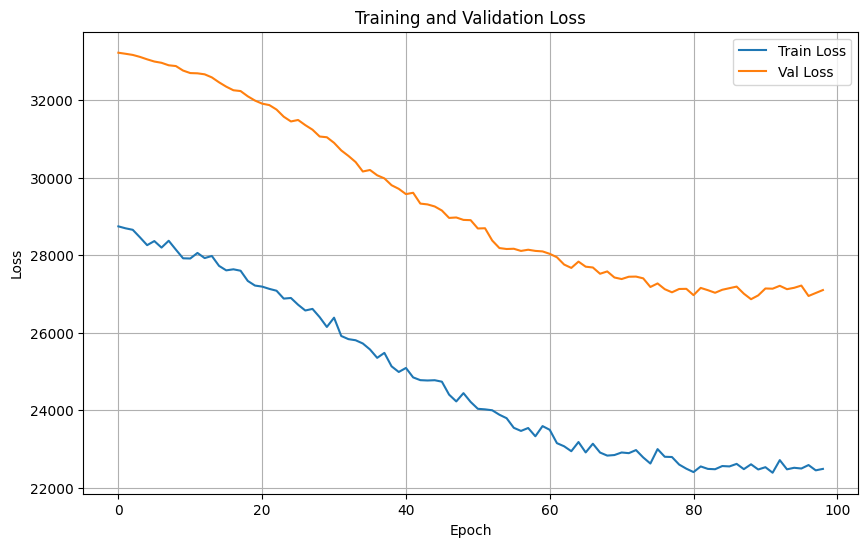

In [22]:
plot_results(train_losses,val_losses)

Let's train a bit more and see

In [23]:
optimizer2 = optim.AdamW(model.parameters(),lr=0.0001,weight_decay=1e-5)
lr_scheduler2 = optim.lr_scheduler.CosineAnnealingLR(optimizer2,T_max=100,eta_min=1e-7)
loss_fn = nn.MSELoss()

train_loop(model,optimizer2,loss_fn,lr_scheduler2,train_dataloader,val_dataloader,train_losses,val_losses,EarlyStopping(11,0.01),epochs=100)

Epoch 1 | Train MSE: 22400.46701388889
Epoch 1 | Train MAE: 132.95963541666666
Epoch 1 | Val Loss: 26926.018880208332
Epoch 1 | Val MAE: 150.98016866048178
EarlyStopping counter: 1/11
EarlyStopping counter: 2/11
EarlyStopping counter: 1/11
EarlyStopping counter: 2/11
EarlyStopping counter: 1/11
EarlyStopping counter: 2/11
Epoch 10 | Train MSE: 22232.72873263889
Epoch 10 | Train MAE: 132.48202768961588
Epoch 10 | Val Loss: 27045.276692708332
Epoch 10 | Val MAE: 151.35698954264322
EarlyStopping counter: 3/11
EarlyStopping counter: 4/11
EarlyStopping counter: 1/11
EarlyStopping counter: 1/11
EarlyStopping counter: 1/11
EarlyStopping counter: 2/11
Epoch 20 | Train MSE: 22318.95290798611
Epoch 20 | Train MAE: 132.61070421006946
Epoch 20 | Val Loss: 26871.827473958332
Epoch 20 | Val MAE: 150.85519409179688
EarlyStopping counter: 3/11
EarlyStopping counter: 1/11
EarlyStopping counter: 1/11
EarlyStopping counter: 2/11
EarlyStopping counter: 1/11
EarlyStopping counter: 2/11
EarlyStopping counte

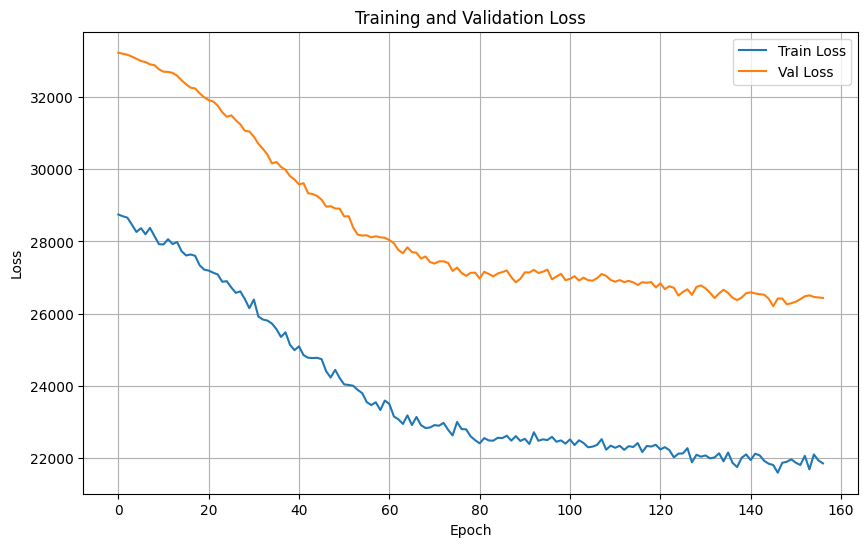

In [24]:
plot_results(train_losses,val_losses)

### Let's Deploy

In [25]:
def test_loop(model,loss_fn,test_dataloader):

    model.eval()
    test_loss = 0.0
    test_mae = 0.0

    with torch.no_grad():
        for X,y in test_dataloader:
            y_pred = model(X)
            loss = loss_fn(y_pred,y)
            mae = torch.abs(y_pred-y).mean()

            test_loss+=loss.item()
            test_mae += mae.item()

    avg_test_loss = test_loss/len(test_dataloader)
    avg_test_mae = test_mae/len(test_dataloader)

    return avg_test_loss,avg_test_mae

In [26]:
test_mse, test_mae = test_loop(model,loss_fn,test_dataloader)
print("Test MSE",test_mse,"Test MAE",test_mae)

Test MSE 20438.4111328125 Test MAE 128.2488021850586


Part 2: Concept Questions (20 min)

1. What's the difference between model.parameters() and model.fc.parameters() when creating an optimizer? When would you use each?

So this has an application when it comes to transfer learning in particular. If you pass model.parameters() into an optimizer, then it's going to make parameter updates to all of the model's layers. But if you pass model.fc.parameters(), then it will only update the parameters in the fc layer, probably because the rest are frozen. I'd use model.parameters() in non-transfer-learning scenarios and in transfer learning if all of the layers are unfrozen. But I'd use model.fc.parameters() initially after freezing all of the layers in transfer learning. 

2. You train a model and get:

Train MAE: 0.8

Val MAE: 0.85

Test MAE: 2.3

What's wrong here? What does this tell you?

The test MAE is super super high. It didn't generalize well at all. This is data leakage.

Explain what happens during optimizer.step(). What actually changes in the model?

This is the parameter update. theta = theta - lr* dtheta/dL